In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

In [9]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'
#DATA_DIR    = '/Users/zoecas/Documents/data/'

DATA_SUBDIR = 'diags_2024/'
filename = 'swot_segments2D_250km_demean.nc'

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── File parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 1000.0
BOX_DEG = 2.0
#filename_pattern = f'{int(SEGMENT_LENGTH_KM)}km_notide_demean_sw6.nc'
#filename_pattern ="1000km_notide_demean_swh6.nc"


# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)

In [15]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    psd2d_all    = ds_segments['psd2D'].values
    wavenumber = ds_segments['wavenumber'].values
    #wavenumber2d = ds_segments['wavenumber2D'].values
    rows_lat, rows_lon, rows_n, rows_psd, rows_psd2d = [], [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_psd2d.append(np.nanmean(psd2d_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    psd2d_stack  = np.stack(rows_psd2d, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            mean_psd2d=(['box', 'wavenumber'], psd2d_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            #wavenumber2D=('wavenumber2D', wavenumber2d, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

from scipy.stats import binned_statistic_2d


def bin_psd_to_grid(lon, lat, psd, wavenumber, dlon=1.0, dlat=1.0,
                     lon_bounds=None, lat_bounds=None):
    """
    Bin scattered (lon, lat) segments with associated PSD(wavenumber)
    into regular lon/lat boxes, averaging over segments within each box.

    Parameters
    ----------
    lon, lat : array-like, 1D, shape (n_segment,)
        Segment mean position (lon_mean, lat_mean).
    psd : array-like, 2D, shape (n_segment, n_wavenumber)
        Non-integrated PSD.
    wavenumber : array-like, 1D, shape (n_wavenumber,)
        Wavenumber coordinate (assumed same for all segments).
    dlon, dlat : float
        Box size in degrees.
    lon_bounds, lat_bounds : tuple(min, max), optional
        Domain extent. Defaults to data min/max.

    Returns
    -------
    xr.Dataset with dims (lat, lon, wavenumber), variables: psd, count
    """
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    psd = np.asarray(psd)              # (n_segment, n_wavenumber)
    wavenumber = np.asarray(wavenumber)

    n_seg, n_k = psd.shape
    assert len(lon) == n_seg and len(lat) == n_seg
    assert len(wavenumber) == n_k

    if lon_bounds is None:
        lon_bounds = (np.nanmin(lon), np.nanmax(lon))
    if lat_bounds is None:
        lat_bounds = (np.nanmin(lat), np.nanmax(lat))

    lon_edges = np.arange(lon_bounds[0], lon_bounds[1] + dlon, dlon)
    lat_edges = np.arange(lat_bounds[0], lat_bounds[1] + dlat, dlat)
    n_lon = len(lon_edges) - 1
    n_lat = len(lat_edges) - 1

    # bin index for each segment (0-based, -1 or n_bins for out-of-range)
    lon_idx = np.digitize(lon, lon_edges) - 1
    lat_idx = np.digitize(lat, lat_edges) - 1

    valid = (lon_idx >= 0) & (lon_idx < n_lon) & (lat_idx >= 0) & (lat_idx < n_lat)

    # flatten (lat, lon) box index for use with bincount
    flat_idx = lat_idx[valid] * n_lon + lon_idx[valid]
    n_boxes = n_lat * n_lon

    psd_valid = psd[valid]             # (n_valid_seg, n_k)

    # sum PSD per box per wavenumber, and count segments per box
    sum_psd = np.zeros((n_boxes, n_k))
    count = np.bincount(flat_idx, minlength=n_boxes).astype(float)

    for k in range(n_k):
        sum_psd[:, k] = np.bincount(flat_idx, weights=psd_valid[:, k], minlength=n_boxes)

    with np.errstate(invalid='ignore', divide='ignore'):
        mean_psd = sum_psd / count[:, None]

    mean_psd = mean_psd.reshape(n_lat, n_lon, n_k)
    count_grid = count.reshape(n_lat, n_lon)

    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    ds_out = xr.Dataset(
        data_vars=dict(
            psd=(("lat", "lon", "wavenumber"), mean_psd),
            count=(("lat", "lon"), count_grid),
        ),
        coords=dict(
            lon=("lon", lon_centers),
            lat=("lat", lat_centers),
            wavenumber=("wavenumber", wavenumber),
        ),
    )
    return ds_out
    
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker


def plot_box(var : xr.DataArray, lon : np.array, lat : np.array,
             projection : ccrs = ccrs.Robinson(), cmap : str="viridis", 
             min_size : int=20, max_size : int=300, figsize : tuple=(14, 7),
             title : str = "Number of observations per box", label : str = "Number of observations",
             fig=None, ax=None,
             norm : norm = None, vmin : float = None, vmax : float = None, box_deg : float = BOX_DEG
            ):
    dims = var.dims
    mask = np.isfinite(var)
    #lon = lon[mask]
    #lat = lat[mask]
    #var = var[mask]
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

    gl.xlabel_style = {"size": 10,"color": "black",}

    gl.ylabel_style = {"size": 10,"color": "black",}
    
    if norm is not None:
        sc = ax.scatter(lon,lat,s=45,c=var,
                    cmap=cmap,edgecolors=None,linewidths=0.25,
                    transform=ccrs.PlateCarree(),norm = norm)
    else:
        if vmin is None:
            vmin,vmax=np.nanmin(var),np.nanmax(var)
        if box_deg <=0.0 :
            sc = ax.pcolormesh(lon,lat,var,
                              cmap=cmap,vmin = vmin, vmax = vmax,
                            transform=ccrs.PlateCarree())
        else:
            if 'lat' in dims:
                sc = ax.pcolormesh(lon,lat,var,
                             cmap=cmap,vmin = vmin, vmax = vmax,
                            transform=ccrs.PlateCarree())
            else:
                sc = ax.scatter(lon,lat,s=45,c=var,
                        cmap=cmap,edgecolors=None,linewidths=0.25,
                        transform=ccrs.PlateCarree(),vmin = vmin, vmax = vmax)

    cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
    cb.set_label(label)
    ax.set_title(title)
    
    return fig, ax

In [12]:
ds = xr.open_dataset(DATA_DIR+DATA_SUBDIR+filename)
#ds_boxes = build_box_dataset(ds,box_deg=BOX_DEG)
ds_boxes = bin_psd_to_grid(ds.lon_mean, ds.lat_mean, ds.psd, ds.wavenumber, dlon=BOX_DEG, dlat=BOX_DEG)
ds

<xarray.Dataset> Size: 2GB
Dimensions:         (segment: 1449547, wavenumber: 63)
Coordinates:
  * segment         (segment) int64 12MB 0 1 2 3 ... 1449544 1449545 1449546
  * wavenumber      (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    psd             (segment, wavenumber) float64 731MB 0.002231 ... 1.181e-05
    psd2D           (segment, wavenumber) float64 731MB ...
    lat_mean        (segment) float64 12MB 27.81 23.38 22.28 ... 58.05 59.08
    lat_min         (segment) float64 12MB ...
    lat_max         (segment) float64 12MB ...
    lon_mean        (segment) float64 12MB 248.1 248.9 249.1 ... 305.5 306.3
    n_pixels_used   (segment) int64 12MB ...
    valid_fraction  (segment) float64 12MB ...
    swath           (segment) <U5 29MB ...
    granule         (segment) <U69 400MB ...
    year            (segment) int64 12MB ...
    month           (segment) int64 12MB ...

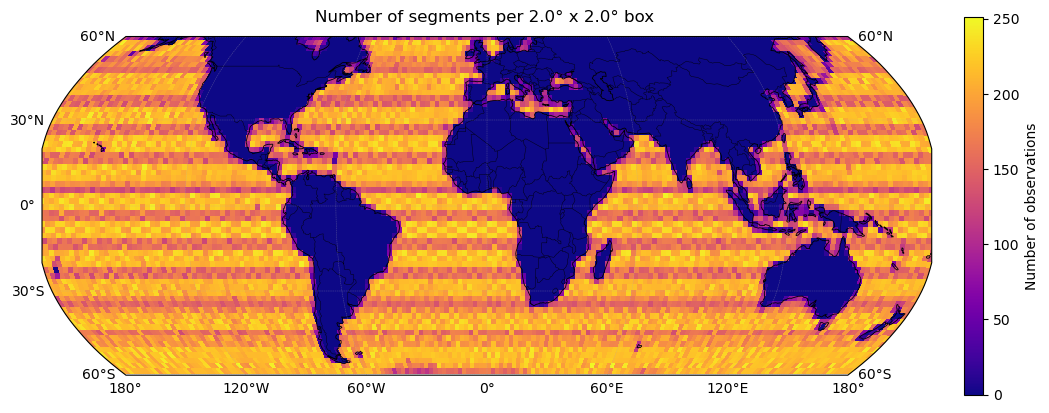

In [17]:
fig, ax = plot_box(ds_boxes["count"],
                   ds_boxes["lon"].values,
                   ds_boxes["lat"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

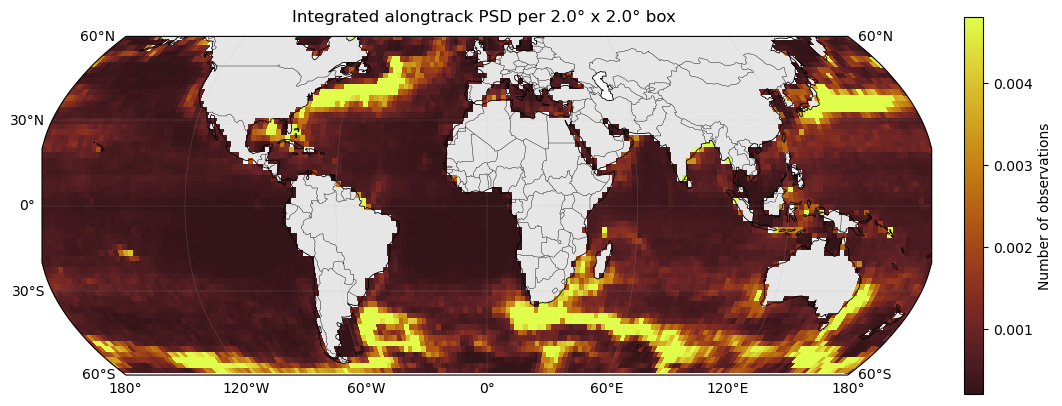

In [18]:
import cmocean

K_MIN, K_MAX = 1/500, 1/6

energy = ds_boxes["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon"],
                   ds_boxes["lat"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

if False:
    energy = ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_boxes["lon_center"],
                       ds_boxes["lat_center"],
                       cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Integrated 2D PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()
    
    ratio = ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')/ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(ratio,
                       ds_boxes["lon_center"],
                       ds_boxes["lat_center"],
                       cmap=cmocean.cm.balance, vmin = 0, vmax = 1,
                       title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

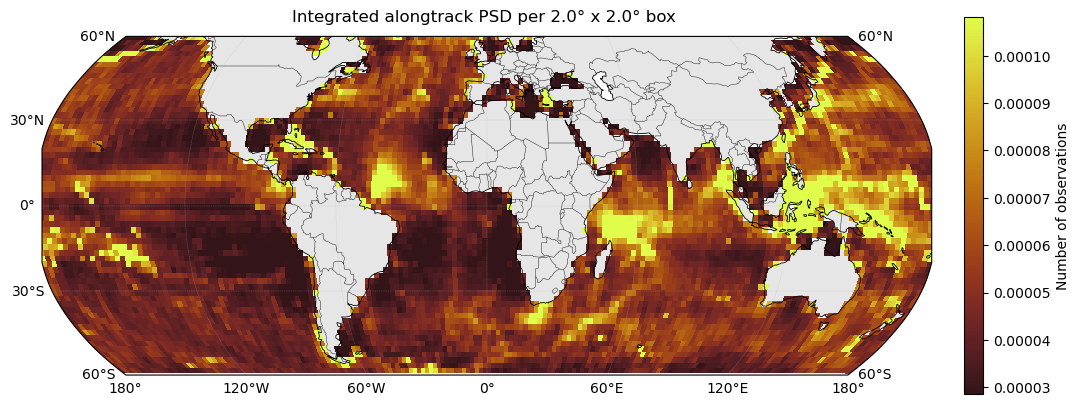

In [19]:
K_MIN, K_MAX = 1/50, 1/6

energy = ds_boxes["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon"],
                   ds_boxes["lat"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

if False:
    energy = ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_boxes["lon_center"],
                       ds_boxes["lat_center"],
                       cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Integrated 2D PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()
    
    ratio = (ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
            )/ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(ratio,
                       ds_boxes["lon_center"],
                       ds_boxes["lat_center"],
                       cmap=cmocean.cm.balance, vmin = 0, vmax = 1,
                       title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

## Amazon Shelf

In [20]:
latmin, latmax = -5, 30
lonmin, lonmax = 280, 330
ds_sub = ds.where((ds.lon_mean<=lonmax) & (ds.lon_mean>=lonmin) &
                  (ds.lat_mean<=latmax) & (ds.lat_mean>=latmin), drop=True)

In [21]:
ds_boxes_01 = bin_psd_to_grid(ds.where(ds.month==1,drop=True).lon_mean,ds.where(ds.month==1,drop=True).lat_mean,
                              ds.where(ds.month==1,drop=True).psd,ds.where(ds.month==1,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
ds_boxes_08 = bin_psd_to_grid(ds.where(ds.month==8,drop=True).lon_mean,ds.where(ds.month==8,drop=True).lat_mean,
                              ds.where(ds.month==8,drop=True).psd,ds.where(ds.month==8,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)

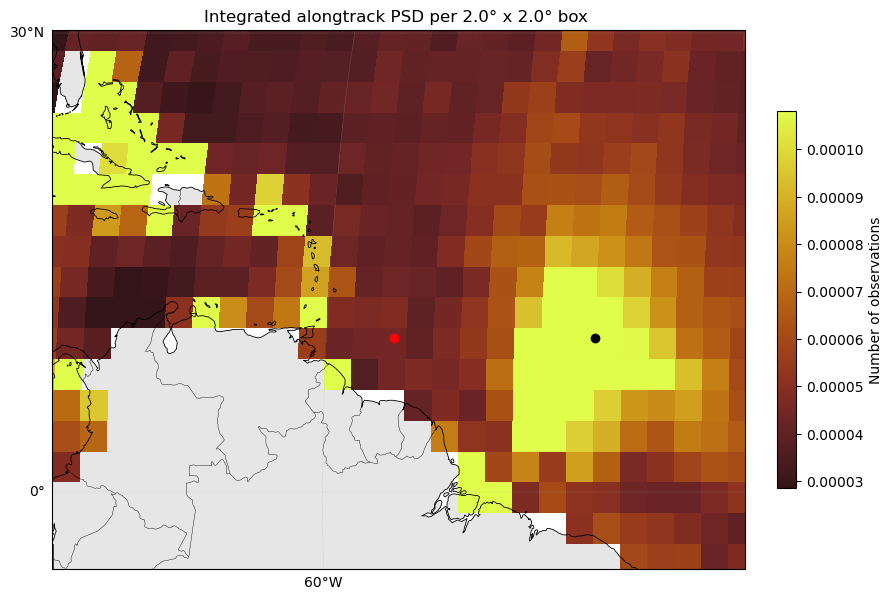

In [22]:
K_MIN, K_MAX = 1/50, 1/6

energy = ds_boxes["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon"],
                   ds_boxes["lat"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([280,330,-5,30], crs=ccrs.PlateCarree())
ax.scatter(320,10, transform=ccrs.PlateCarree(),c='k')
ax.scatter(305,10, transform=ccrs.PlateCarree(),c='r')
plt.show()

if False:
    energy = ds_boxes_01["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_boxes_01["lon"],
                       ds_boxes_01["lat"],
                       cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
    ax.set_extent([280,330,-5,30], crs=ccrs.PlateCarree())
    ax.scatter(320,10, transform=ccrs.PlateCarree(),c='k')
    ax.scatter(305,10, transform=ccrs.PlateCarree(),c='r')
    plt.show()
    
    energy = ds_boxes_08["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_boxes_08["lon_center"],
                       ds_boxes_08["lat_center"],
                       cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
    ax.set_extent([280,330,-5,30], crs=ccrs.PlateCarree())
    ax.scatter(320,10, transform=ccrs.PlateCarree(),c='k')
    ax.scatter(305,10, transform=ccrs.PlateCarree(),c='r')
    plt.show()

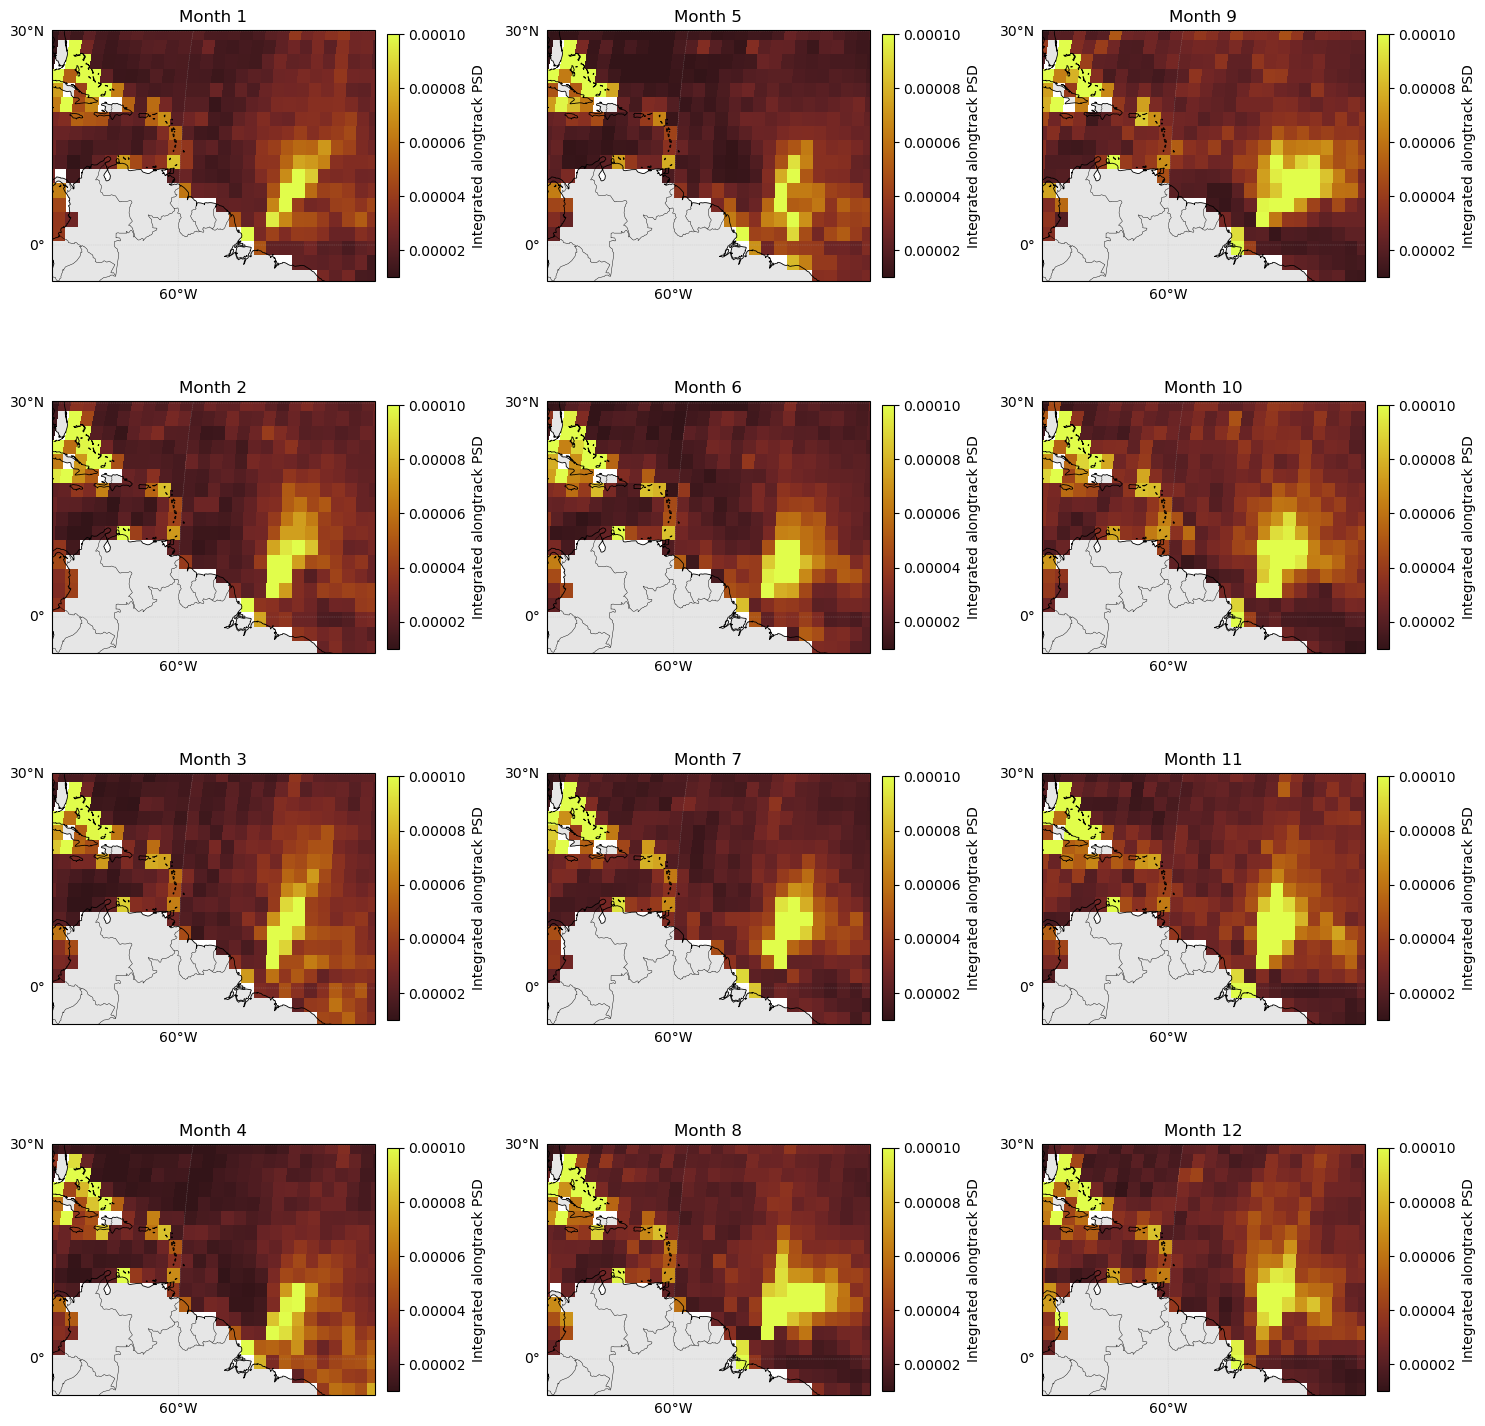

In [23]:
K_MIN, K_MAX = 1/30, 1/10

fig,axs = plt.subplots(4,3,figsize=(15,15),
                      subplot_kw={"projection": ccrs.Robinson()})
for i in range(4):
    ds_binned = bin_psd_to_grid(ds.where(ds.month==i+1,drop=True).lon_mean,ds.where(ds.month==i+1,drop=True).lat_mean,
                              ds.where(ds.month==i+1,drop=True).psd,ds.where(ds.month==i+1,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
    energy = ds_binned["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_binned["lon"],
                       ds_binned["lat"],
                       cmap=cmocean.cm.solar, vmax = 1e-4, vmin = 1e-5,
                       #vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Month {i+1}",
                      label='Integrated alongtrack PSD',fig=fig,ax=axs[i,0])
    ax.set_extent([lonmin,lonmax,latmin,latmax], crs=ccrs.PlateCarree())
    #ax.plot([40,75],[-8,-8], transform=ccrs.PlateCarree(), c='k')
    #ax.plot([40,75],[-15,-15], transform=ccrs.PlateCarree(), c='k',ls='--')
    #ax.plot([63,63],[-22,8], transform=ccrs.PlateCarree(), c='r',ls='--')
for i in range(4):
    ds_binned = bin_psd_to_grid(ds.where(ds.month==i+5,drop=True).lon_mean,ds.where(ds.month==i+5,drop=True).lat_mean,
                              ds.where(ds.month==i+5,drop=True).psd,ds.where(ds.month==i+5,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
    energy = ds_binned["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_binned["lon"],
                       ds_binned["lat"],
                       cmap=cmocean.cm.solar,vmax = 1e-4, vmin = 1e-5,
                       #vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Month {i+5}",
                      label='Integrated alongtrack PSD',fig=fig,ax=axs[i,1])
    ax.set_extent([lonmin,lonmax,latmin,latmax], crs=ccrs.PlateCarree())
    #ax.plot([40,75],[-8,-8], transform=ccrs.PlateCarree(), c='k')
    #ax.plot([40,75],[-15,-15], transform=ccrs.PlateCarree(), c='k',ls='--')
    #ax.plot([63,63],[-22,8], transform=ccrs.PlateCarree(), c='r',ls='--')
for i in range(4):
    ds_binned = bin_psd_to_grid(ds.where(ds.month==i+9,drop=True).lon_mean,ds.where(ds.month==i+9,drop=True).lat_mean,
                              ds.where(ds.month==i+9,drop=True).psd,ds.where(ds.month==i+9,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
    energy = ds_binned["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_binned["lon"],
                       ds_binned["lat"],
                       cmap=cmocean.cm.solar,vmax = 1e-4, vmin = 1e-5,
                       #vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Month {i+9}",
                      label='Integrated alongtrack PSD',fig=fig,ax=axs[i,2])
    ax.set_extent([lonmin,lonmax,latmin,latmax], crs=ccrs.PlateCarree())
    #ax.plot([40,75],[-8,-8], transform=ccrs.PlateCarree(), c='k')
    #ax.plot([40,75],[-15,-15], transform=ccrs.PlateCarree(), c='k',ls='--')
    #ax.plot([63,63],[-22,8], transform=ccrs.PlateCarree(), c='r',ls='--')
    #ax.scatter(55,-21, transform=ccrs.PlateCarree(),c='r')
#ax.scatter(305,10, transform=ccrs.PlateCarree(),c='r')
fig.tight_layout()
plt.show()

In [24]:
dlat, dlon = 0.5, 0.5
latc, lonc, lonc2 = 10.0, 320.0, 305.0
ds_pt = ds_sub.where((ds_sub.lat_mean<=latc+dlat) & (ds_sub.lat_mean>=latc-dlat) &
                    (ds_sub.lon_mean<=lonc+dlon) & (ds_sub.lon_mean>=lonc-dlon), drop=True)

ds_pt2 = ds_sub.where((ds_sub.lat_mean<=latc+dlat) & (ds_sub.lat_mean>=latc-dlat) &
                    (ds_sub.lon_mean<=lonc2+dlon) & (ds_sub.lon_mean>=lonc2-dlon), drop=True)


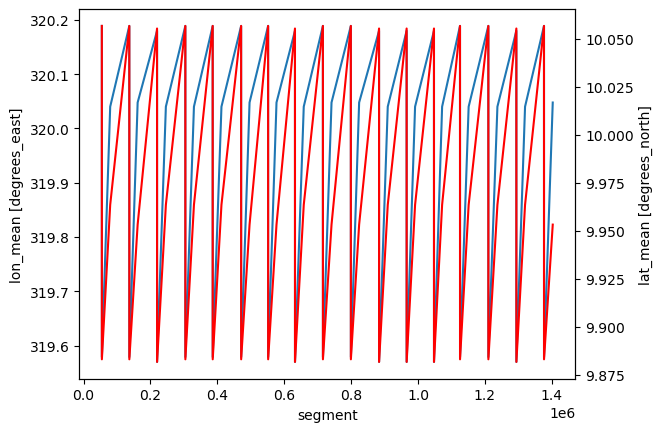

In [25]:
ds_pt.lon_mean.plot()
plt.twinx()
ds_pt.lat_mean.plot(c='r')

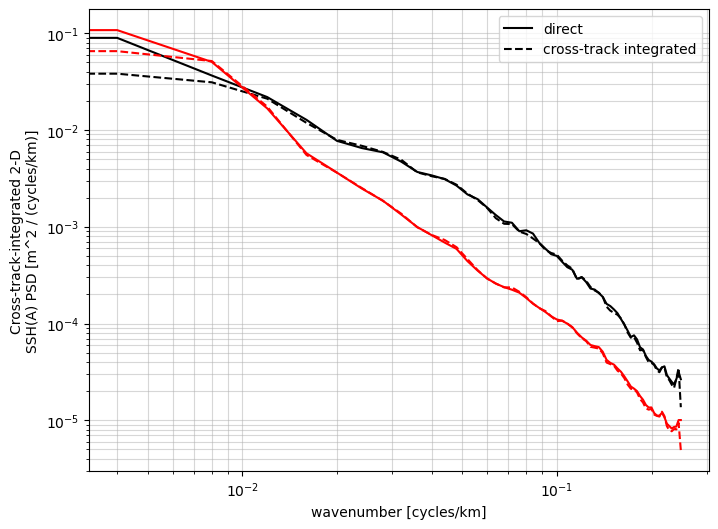

In [26]:
fig,ax = plt.subplots(figsize=(8,6))
ds_pt.psd.mean('segment').plot(ax=ax, c='k', xscale='log',yscale='log', label='direct')
ds_pt.psd2D.mean('segment').plot(ax=ax, c='k', ls='--', xscale='log',yscale='log', label='cross-track integrated')
ds_pt2.psd.mean('segment').plot(ax=ax, c='r', xscale='log',yscale='log')
ds_pt2.psd2D.mean('segment').plot(ax=ax, c='r', ls='--', xscale='log',yscale='log')
ax.grid(True,which='both',alpha=0.5);
ax.legend()

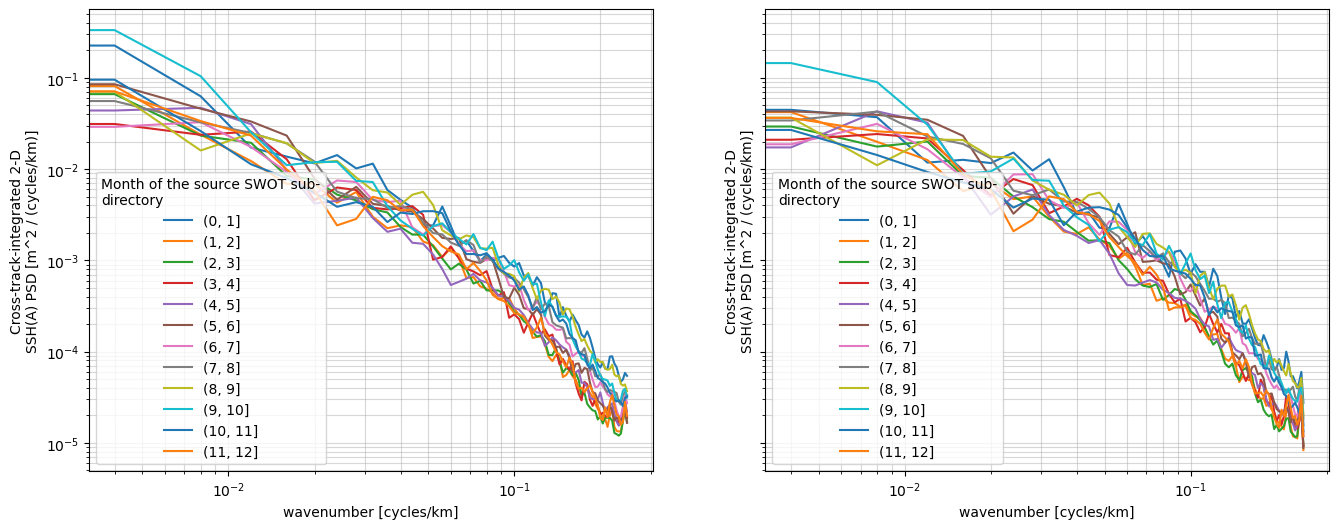

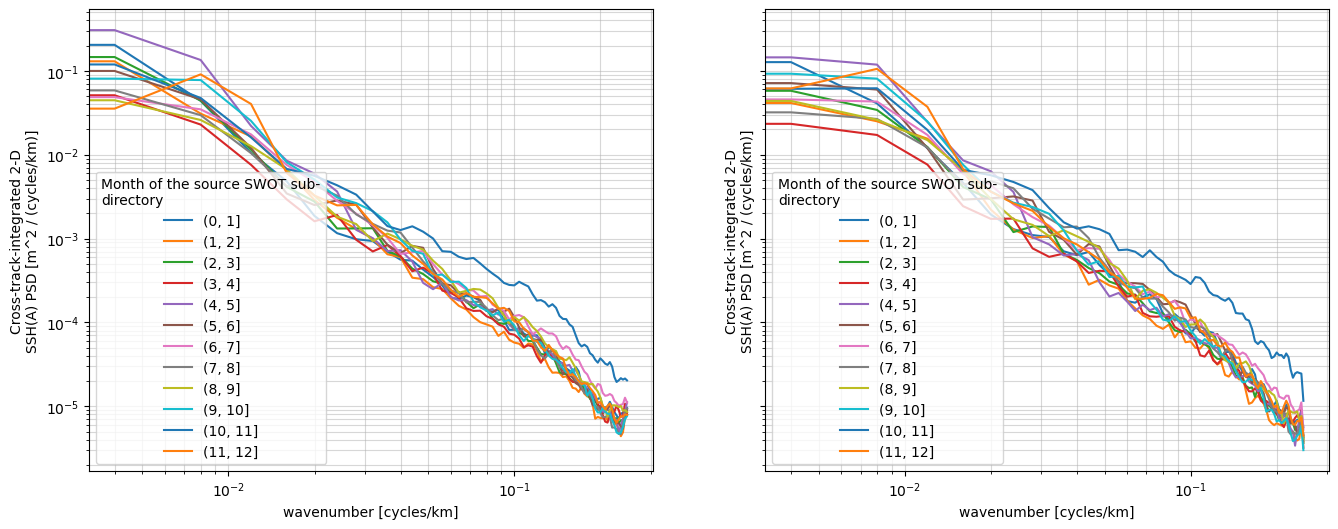

In [27]:
monthly_binned = ds_pt.groupby_bins('month',bins=np.arange(0,13)).mean()
monthly_binned2 = ds_pt2.groupby_bins('month',bins=np.arange(0,13)).mean()

fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
monthly_binned.psd.plot(ax=axs[0], hue='month_bins', xscale='log',yscale='log')
monthly_binned.psd2D.plot(ax=axs[1], hue='month_bins', xscale='log',yscale='log')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
    #ax.legend()

fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
monthly_binned2.psd.plot(ax=axs[0], hue='month_bins', xscale='log',yscale='log')
monthly_binned2.psd2D.plot(ax=axs[1], hue='month_bins', xscale='log',yscale='log')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);

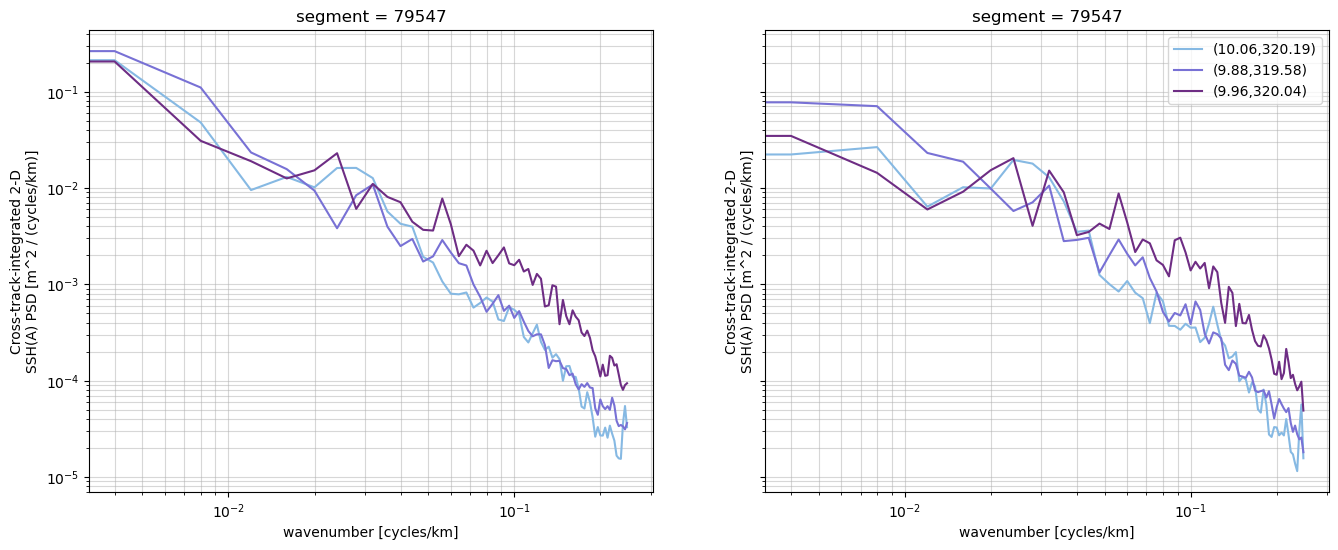

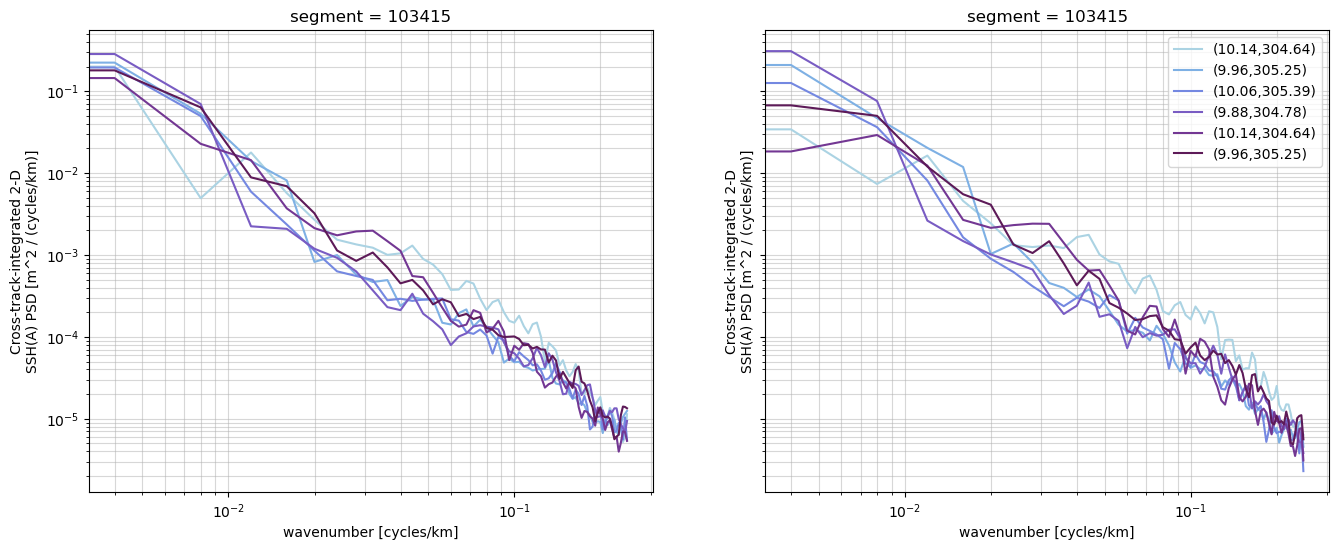

In [28]:
cmap = plt.get_cmap(cmocean.cm.dense)

norm = plt.Normalize(vmin=-1, vmax=ds_pt.where(ds_pt.month==1,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt.where(ds_pt.month==1,drop=True).segment):
    _s = ds_pt.where(ds_pt.month==1,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()


norm = plt.Normalize(vmin=-1, vmax=ds_pt2.where(ds_pt2.month==1,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt2.where(ds_pt2.month==1,drop=True).segment):
    _s = ds_pt2.where(ds_pt2.month==1,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()

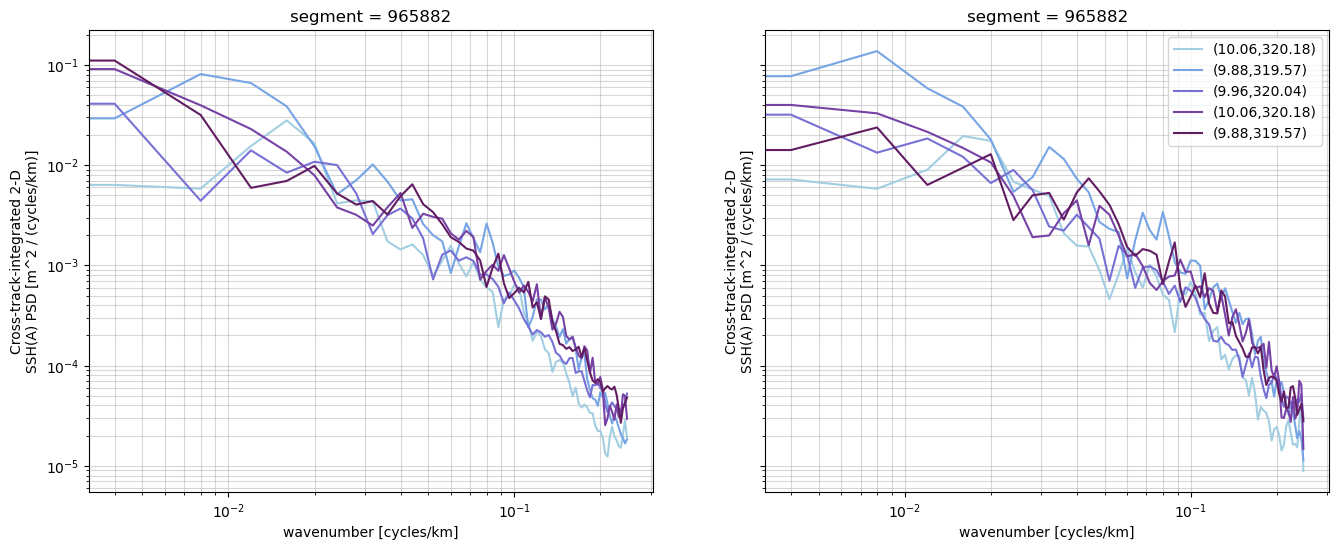

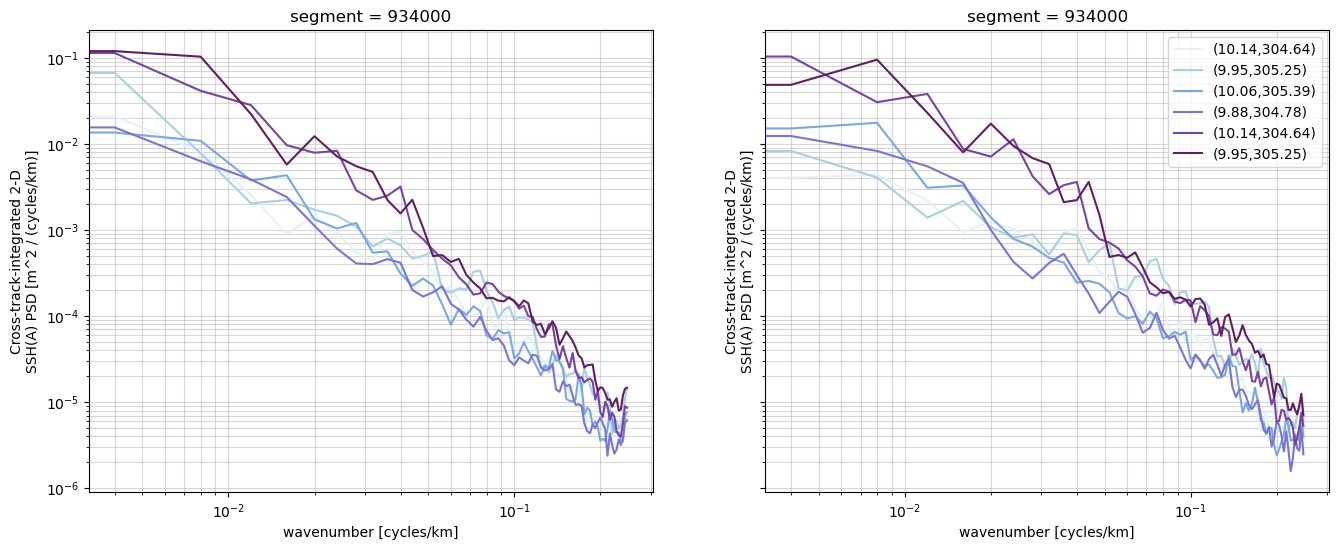

In [29]:
cmap = plt.get_cmap(cmocean.cm.dense)

norm = plt.Normalize(vmin=-1, vmax=ds_pt.where(ds_pt.month==8,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt.where(ds_pt.month==8,drop=True).segment):
    _s = ds_pt.where(ds_pt.month==8,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()


norm = plt.Normalize(vmin=0.1, vmax=ds_pt2.where(ds_pt2.month==8,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt2.where(ds_pt2.month==8,drop=True).segment):
    _s = ds_pt2.where(ds_pt2.month==8,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()

## Mascarene:

In [30]:
latmin, latmax = -22, 8
lonmin, lonmax = 40, 75
ds_sub = ds.where((ds.lon_mean<=lonmax) & (ds.lon_mean>=lonmin) &
                  (ds.lat_mean<=latmax) & (ds.lat_mean>=latmin), drop=True)
ds_sub

<xarray.Dataset> Size: 48MB
Dimensions:         (segment: 44055, wavenumber: 63)
Coordinates:
  * segment         (segment) int64 352kB 189 190 191 ... 1448038 1448039
  * wavenumber      (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    psd             (segment, wavenumber) float64 22MB 0.03645 ... 1.343e-05
    psd2D           (segment, wavenumber) float64 22MB 0.02168 ... 7.446e-06
    lat_mean        (segment) float64 352kB -19.88 -18.76 -17.66 ... 6.629 7.738
    lat_min         (segment) float64 352kB -21.02 -19.92 -18.81 ... 5.484 6.593
    lat_max         (segment) float64 352kB -18.73 -17.61 -16.5 ... 7.774 8.883
    lon_mean        (segment) float64 352kB 55.93 56.13 56.32 ... 59.4 59.57
    n_pixels_used   (segment) float64 352kB 27.0 27.0 27.0 ... 27.0 27.0 27.0
    valid_fraction  (segment) float64 352kB 0.7441 0.7838 ... 0.7217 0.7207
    swath           (segment) object 352kB 'left' 'left' ... 'right' 'right'
    granule         (segment) object 352kB 'SWOT_L2_LR_SSH_Expert_008_497_202...
    year            (segment) float64 352kB 2.024e+03 2.024e+03 ... 2.024e+03
    month           (segment) float64 352kB 1.0 1.0 1.0 1.0 ... 12.0 12.0 12.0

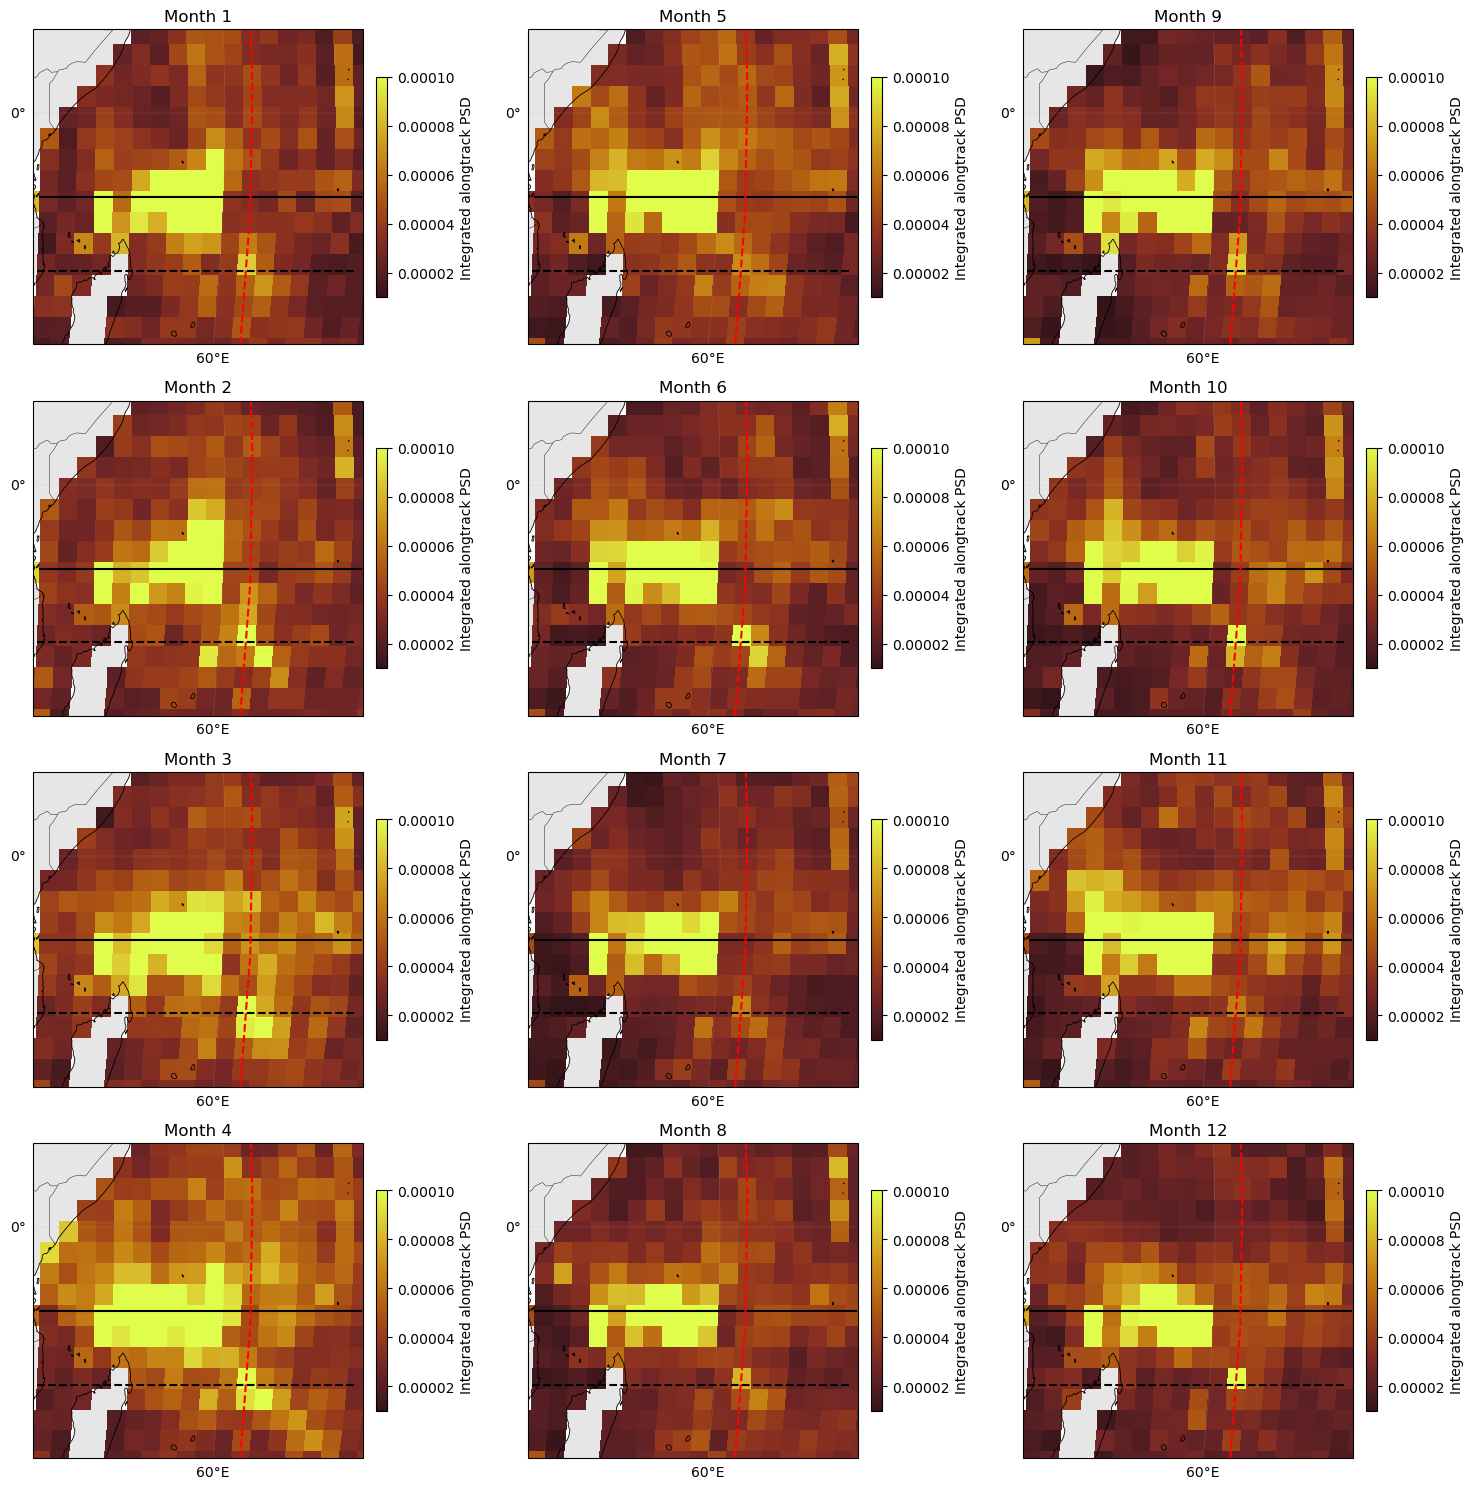

In [31]:
K_MIN, K_MAX = 1/30, 1/10

fig,axs = plt.subplots(4,3,figsize=(15,15),
                      subplot_kw={"projection": ccrs.Robinson()})
for i in range(4):
    ds_binned = bin_psd_to_grid(ds.where(ds.month==i+1,drop=True).lon_mean,ds.where(ds.month==i+1,drop=True).lat_mean,
                              ds.where(ds.month==i+1,drop=True).psd,ds.where(ds.month==i+1,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
    energy = ds_binned["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_binned["lon"],
                       ds_binned["lat"],
                       cmap=cmocean.cm.solar, vmax = 1e-4, vmin = 1e-5,
                       #vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Month {i+1}",
                      label='Integrated alongtrack PSD',fig=fig,ax=axs[i,0])
    ax.set_extent([lonmin,lonmax,latmin,latmax], crs=ccrs.PlateCarree())
    ax.plot([40,75],[-8,-8], transform=ccrs.PlateCarree(), c='k')
    ax.plot([40,75],[-15,-15], transform=ccrs.PlateCarree(), c='k',ls='--')
    ax.plot([63,63],[-22,8], transform=ccrs.PlateCarree(), c='r',ls='--')
for i in range(4):
    ds_binned = bin_psd_to_grid(ds.where(ds.month==i+5,drop=True).lon_mean,ds.where(ds.month==i+5,drop=True).lat_mean,
                              ds.where(ds.month==i+5,drop=True).psd,ds.where(ds.month==i+5,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
    energy = ds_binned["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_binned["lon"],
                       ds_binned["lat"],
                       cmap=cmocean.cm.solar,vmax = 1e-4, vmin = 1e-5,
                       #vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Month {i+5}",
                      label='Integrated alongtrack PSD',fig=fig,ax=axs[i,1])
    ax.set_extent([lonmin,lonmax,latmin,latmax], crs=ccrs.PlateCarree())
    ax.plot([40,75],[-8,-8], transform=ccrs.PlateCarree(), c='k')
    ax.plot([40,75],[-15,-15], transform=ccrs.PlateCarree(), c='k',ls='--')
    ax.plot([63,63],[-22,8], transform=ccrs.PlateCarree(), c='r',ls='--')
for i in range(4):
    ds_binned = bin_psd_to_grid(ds.where(ds.month==i+9,drop=True).lon_mean,ds.where(ds.month==i+9,drop=True).lat_mean,
                              ds.where(ds.month==i+9,drop=True).psd,ds.where(ds.month==i+9,drop=True).wavenumber,
                              dlon=BOX_DEG, dlat=BOX_DEG)
    energy = ds_binned["psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,
                       ds_binned["lon"],
                       ds_binned["lat"],
                       cmap=cmocean.cm.solar,vmax = 1e-4, vmin = 1e-5,
                       #vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                       title=f"Month {i+9}",
                      label='Integrated alongtrack PSD',fig=fig,ax=axs[i,2])
    ax.set_extent([lonmin,lonmax,latmin,latmax], crs=ccrs.PlateCarree())
    ax.plot([40,75],[-8,-8], transform=ccrs.PlateCarree(), c='k')
    ax.plot([40,75],[-15,-15], transform=ccrs.PlateCarree(), c='k',ls='--')
    ax.plot([63,63],[-22,8], transform=ccrs.PlateCarree(), c='r',ls='--')
    #ax.scatter(55,-21, transform=ccrs.PlateCarree(),c='r')
#ax.scatter(305,10, transform=ccrs.PlateCarree(),c='r')
fig.tight_layout()
plt.show()

In [32]:
dlat, dlon = 0.45, 0.5
latc, lonc, latc2 = -8.0, 63.0, -15.0
ds_pt = ds_sub.where((ds_sub.lat_mean<=latc+dlat) & (ds_sub.lat_mean>=latc-dlat),drop=True)
                    #(ds_sub.lon_mean<=lonc+dlon) & (ds_sub.lon_mean>=lonc-dlon), drop=True)

ds_pt2 = ds_sub.where((ds_sub.lat_mean<=latc2+dlat) & (ds_sub.lat_mean>=latc2-dlat),drop=True)
ds_pt3 = ds_sub.where((ds_sub.lon_mean<=lonc+dlon) & (ds_sub.lon_mean>=lonc-dlon),drop=True)
#                    (ds_sub.lon_mean<=lonc2+dlon) & (ds_sub.lon_mean>=lonc2-dlon), drop=True)

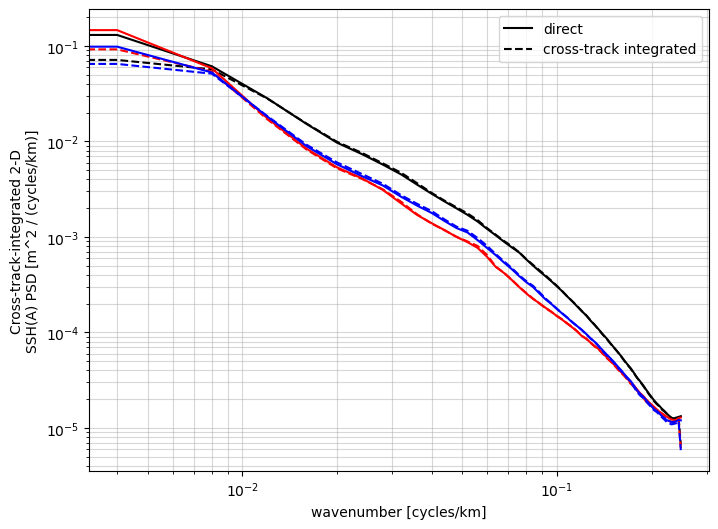

In [33]:
fig,ax = plt.subplots(figsize=(8,6))
ds_pt.psd.mean('segment').plot(ax=ax, c='k', xscale='log',yscale='log', label='direct')
ds_pt.psd2D.mean('segment').plot(ax=ax, c='k', ls='--', xscale='log',yscale='log', label='cross-track integrated')
ds_pt2.psd.mean('segment').plot(ax=ax, c='r', xscale='log',yscale='log')
ds_pt2.psd2D.mean('segment').plot(ax=ax, c='r', ls='--', xscale='log',yscale='log')
ds_pt3.psd.mean('segment').plot(ax=ax, c='b', xscale='log',yscale='log')
ds_pt3.psd2D.mean('segment').plot(ax=ax, c='b', ls='--', xscale='log',yscale='log')
ax.grid(True,which='both',alpha=0.5);
ax.legend()

Text(0.5, 1.0, 'Longtiude: 63.0°E')

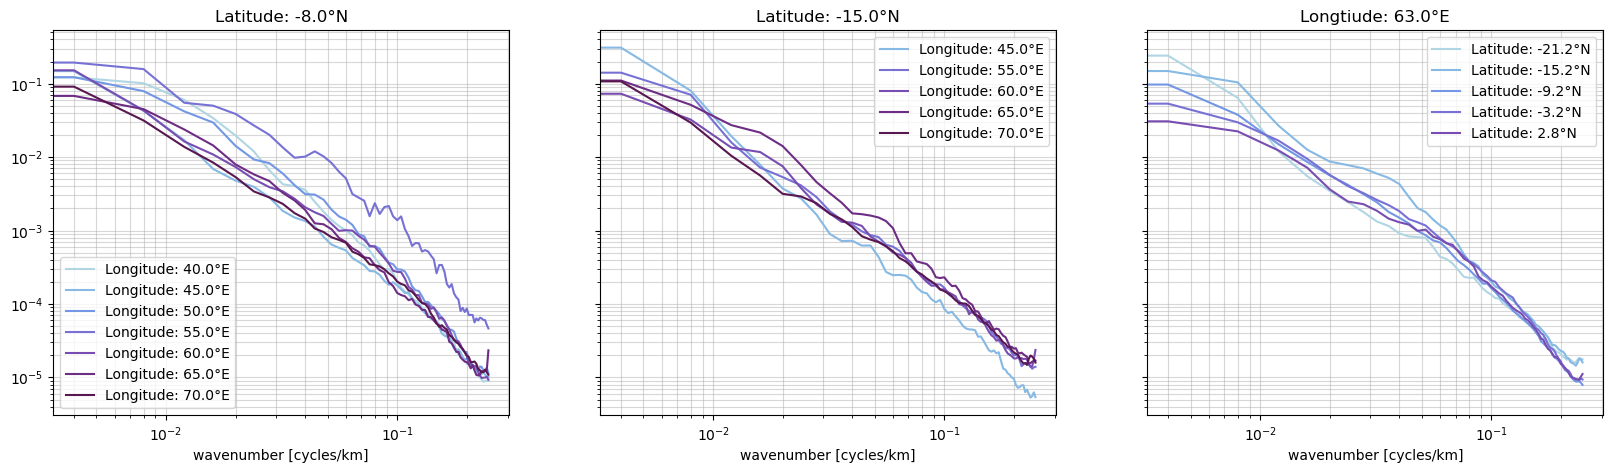

In [34]:
lon_edges = np.arange(ds_pt.lon_mean.min(),ds_pt.lon_mean.max(),5)
lat_edges = np.arange(ds_pt3.lat_mean.min(),ds_pt3.lat_mean.max(),6)
dlon = 0.2
dlon2 = 0.5
dlat=0.5

cmap = plt.get_cmap(cmocean.cm.dense)
norm = plt.Normalize(vmin=-1, vmax=lon_edges.size)

fig,axs = plt.subplots(1,3,figsize=(20,5),sharey=True)
for i,l in enumerate(lon_edges):
    _ = ds_pt.where((ds_pt.lon_mean>=l-dlon) & (ds_pt.lon_mean<=l+dlon),drop=True)
    _2 = ds_pt2.where((ds_pt2.lon_mean>=l-dlon2) & (ds_pt2.lon_mean<=l+dlon2),drop=True)
    _.psd.mean('segment').plot(ax=axs[0], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Longitude: {l:.1f}°E')
    if _2.segment.size>0:
        _2.psd.mean('segment').plot(ax=axs[1], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Longitude: {l:.1f}°E')
        
for i,l in enumerate(lat_edges):
    _ = ds_pt3.where((ds_pt3.lat_mean>=l-dlat) & (ds_pt3.lat_mean<=l+dlat),drop=True)
    _.psd.mean('segment').plot(ax=axs[2], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Latitude: {l:.1f}°N')
    
for ax in axs:
    ax.legend();
    ax.grid(True, which='both',alpha=0.5)
    ax.set_ylabel('')
axs[0].set_title(f'Latitude: {latc}°N')
axs[1].set_title(f'Latitude: {latc2}°N')
axs[2].set_title(f'Longtiude: {lonc}°E')

Text(0.5, 1.0, 'Longtiude: 63.0°E')

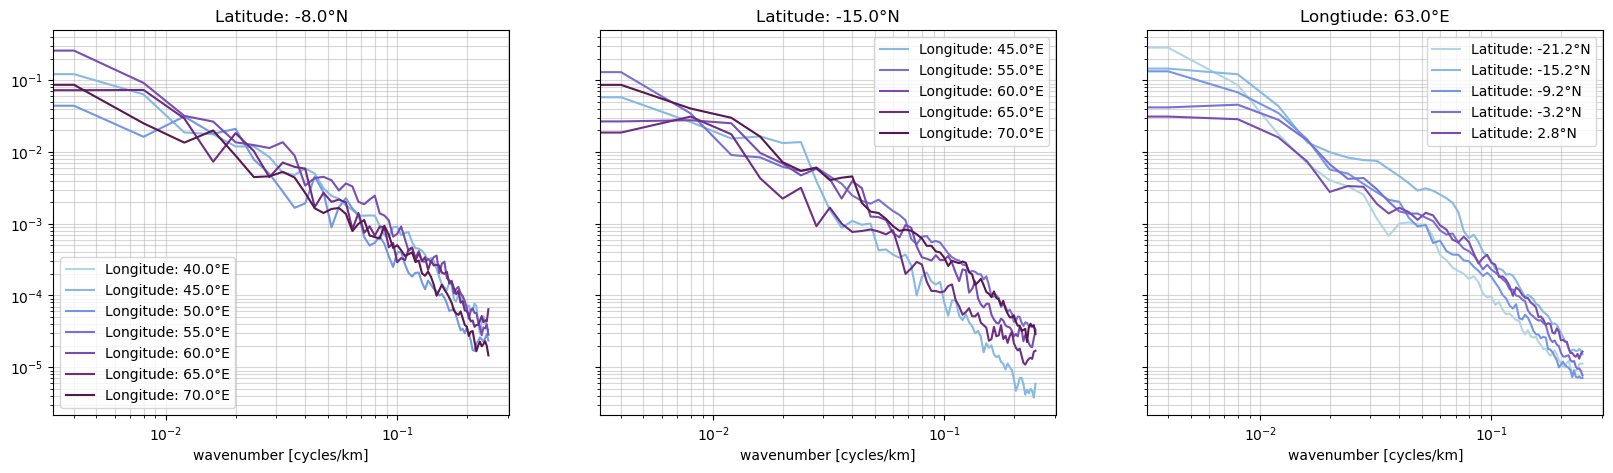

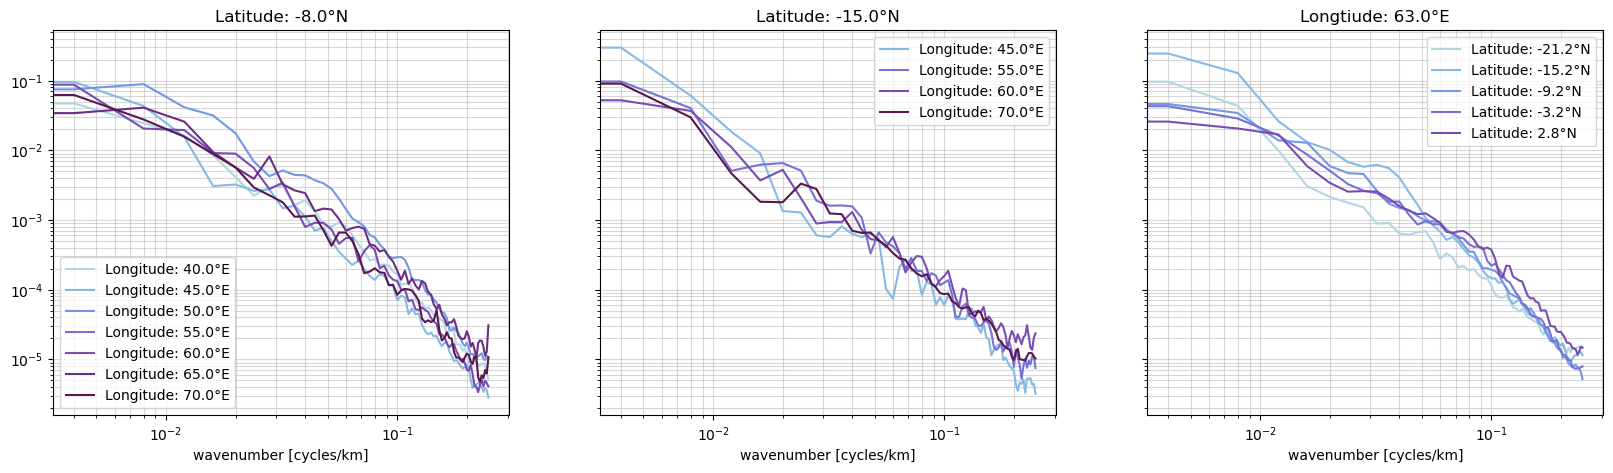

In [35]:
fig,axs = plt.subplots(1,3,figsize=(20,5),sharey=True)
for i,l in enumerate(lon_edges):
    _ = ds_pt.where((ds_pt.lon_mean>=l-dlon) & (ds_pt.lon_mean<=l+dlon) & (ds_pt.month==4),drop=True)
    _2 = ds_pt2.where((ds_pt2.lon_mean>=l-dlon2) & (ds_pt2.lon_mean<=l+dlon2) & (ds_pt2.month==4),drop=True)
    _.psd.mean('segment').plot(ax=axs[0], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Longitude: {l:.1f}°E')
    if _2.segment.size>0:
        _2.psd.mean('segment').plot(ax=axs[1], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Longitude: {l:.1f}°E')
        
for i,l in enumerate(lat_edges):
    _ = ds_pt3.where((ds_pt3.lat_mean>=l-dlat) & (ds_pt3.lat_mean<=l+dlat) & (ds_pt3.month==4),drop=True)
    _.psd.mean('segment').plot(ax=axs[2], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Latitude: {l:.1f}°N')
    
for ax in axs:
    ax.legend();
    ax.grid(True, which='both',alpha=0.5)
    ax.set_ylabel('')
axs[0].set_title(f'Latitude: {latc}°N')
axs[1].set_title(f'Latitude: {latc2}°N')
axs[2].set_title(f'Longtiude: {lonc}°E')

fig,axs = plt.subplots(1,3,figsize=(20,5),sharey=True)
for i,l in enumerate(lon_edges):
    _ = ds_pt.where((ds_pt.lon_mean>=l-dlon) & (ds_pt.lon_mean<=l+dlon) & (ds_pt.month==11),drop=True)
    _2 = ds_pt2.where((ds_pt2.lon_mean>=l-dlon2) & (ds_pt2.lon_mean<=l+dlon2) & (ds_pt2.month==11),drop=True)
    _.psd.mean('segment').plot(ax=axs[0], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Longitude: {l:.1f}°E')
    if _2.segment.size>0:
        _2.psd.mean('segment').plot(ax=axs[1], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Longitude: {l:.1f}°E')
        
for i,l in enumerate(lat_edges):
    _ = ds_pt3.where((ds_pt3.lat_mean>=l-dlat) & (ds_pt3.lat_mean<=l+dlat) & (ds_pt3.month==11),drop=True)
    _.psd.mean('segment').plot(ax=axs[2], c=cmap(norm(i)), xscale='log',yscale='log', label=f'Latitude: {l:.1f}°N')
    
for ax in axs:
    ax.legend();
    ax.grid(True, which='both',alpha=0.5)
    ax.set_ylabel('')
axs[0].set_title(f'Latitude: {latc}°N')
axs[1].set_title(f'Latitude: {latc2}°N')
axs[2].set_title(f'Longtiude: {lonc}°E')

In [18]:
lat = np.unique(ds_boxes.lat_center)
lon = np.unique(ds_boxes.lon_center)
print(lon.size*lat.size,ds_boxes.box.size)

42480 19851
